In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
res_csv = Path.cwd().parent / "data/sota_model_results.csv"

In [3]:
df = pd.read_csv(res_csv)

In [4]:
(df["avg_score_all"] == df["accuracy_all"]).value_counts()

True    56
Name: count, dtype: int64

In [5]:
df

,task,assistant_model,conv_type,n_convs,avg_score_cond,accuracy_cond,n_with_score,n_with_is_correct,avg_score_all,accuracy_all,n_missing_eval,n_both_present,n_mismatch_both_present,missing_eval_rate,mismatch_rate_among_both_present
0,actions,gpt-5,full,105,0.927835,0.857143,97,105,0.857143,0.857143,0,97,0,0.0,0.0
1,actions,gpt-5,sharded,105,0.561905,0.561905,105,105,0.561905,0.561905,0,105,0,0.0,0.0
2,actions,gpt-5-chat,full,105,0.971429,0.971429,105,105,0.971429,0.971429,0,105,0,0.0,0.0
3,actions,gpt-5-chat,sharded,104,0.757282,0.750000,103,104,0.750000,0.750000,0,103,0,0.0,0.0
4,actions,gpt-5-mini,full,105,0.885417,0.809524,96,105,0.809524,0.809524,0,96,0,0.0,0.0
5,actions,gpt-5-mini,sharded,104,0.557692,0.557692,104,104,0.557692,0.557692,0,104,0,0.0,0.0
6,actions,gpt-5.1,full,105,0.934211,0.676190,76,105,0.676190,0.676190,0,76,0,0.0,0.0
7,actions,gpt-5.1,sharded,103,0.584158,0.572816,101,103,0.572816,0.572816,0,101,0,0.0,0.0
8,actions,gpt-5.1-chat,full,105,0.923077,0.914286,104,105,0.914286,0.914286,0,104,0,0.0,0.0
9,actions,gpt-5.1-chat,sharded,104,0.582524,0.576923,103,104,0.576923,0.576923,0,103,0,0.0,0.0


In [6]:
# relevant columns
relevant_cols = ["task", "assistant_model", "conv_type", "accuracy_all", "n_convs"]
df_relevant = df[relevant_cols]
df_relevant

,task,assistant_model,conv_type,accuracy_all,n_convs
0,actions,gpt-5,full,0.857143,105
1,actions,gpt-5,sharded,0.561905,105
2,actions,gpt-5-chat,full,0.971429,105
3,actions,gpt-5-chat,sharded,0.750000,104
4,actions,gpt-5-mini,full,0.809524,105
5,actions,gpt-5-mini,sharded,0.557692,104
6,actions,gpt-5.1,full,0.676190,105
7,actions,gpt-5.1,sharded,0.572816,103
8,actions,gpt-5.1-chat,full,0.914286,105
9,actions,gpt-5.1-chat,sharded,0.576923,104


In [7]:
# artificial analysis intelligence index values
# all medium reasoning effort
a2i2 = {
    "gpt-5-mini": 39,
    "gpt-5": 42,
    # MADE UP VALUE INTERPOLATED BETWEEN 5 AND 5.2
    # ARTIFICIAL ANALYSIS DOES NOT HAVE GPT-5.1 (medium)
    "gpt-5.1": 44, 
    "gpt-5.2": 47,
}

In [8]:
# Define model order for x-axis
model_order = ["gpt-5-mini", "gpt-5", "gpt-5-chat", "gpt-5.1", "gpt-5.1-chat", "gpt-5.2", "gpt-5.2-chat"]

# Pivot data for easier plotting
df_pivot = df_relevant.pivot_table(
    index=["task", "assistant_model"], 
    columns="conv_type", 
    values="accuracy_all"
).reset_index()
df_pivot

conv_type,task,assistant_model,full,sharded
0,actions,gpt-5,0.857143,0.561905
1,actions,gpt-5-chat,0.971429,0.750000
2,actions,gpt-5-mini,0.809524,0.557692
3,actions,gpt-5.1,0.676190,0.572816
4,actions,gpt-5.1-chat,0.914286,0.576923
5,actions,gpt-5.2,0.895238,0.300971
6,actions,gpt-5.2-chat,0.819048,0.466019
7,code,gpt-5,0.290000,0.584615
8,code,gpt-5-chat,0.960000,0.783505
9,code,gpt-5-mini,0.440000,0.344444


In [9]:
import numpy as np

def plot_task_bars(df_pivot, task, ax=None, show_legend=True):
    """Plot side-by-side bars for full vs sharded performance for a single task."""
    task_data = df_pivot[df_pivot["task"] == task].copy()
    task_data["assistant_model"] = pd.Categorical(
        task_data["assistant_model"], categories=model_order, ordered=True
    )
    task_data = task_data.sort_values("assistant_model")
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 6))
    
    x = np.arange(len(model_order))
    width = 0.35
    
    full_vals = task_data["full"].values
    sharded_vals = task_data["sharded"].values
    
    bars1 = ax.bar(x - width/2, full_vals, width, label="Full", color="#eb6f92", alpha=0.8)
    bars2 = ax.bar(x + width/2, sharded_vals, width, label="Sharded", color="#31748f", alpha=0.8)
    
    ax.set_ylabel("Accuracy")
    ax.set_xlabel("Model")
    ax.set_title(f"Full vs Sharded Performance: {task.capitalize()}")
    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=45, ha="right")
    ax.set_ylim(0, 1.05)
    ax.axhline(y=1.0, color="gray", linestyle="--", alpha=0.3)
    
    if show_legend:
        ax.legend(loc="upper right")
    
    return ax

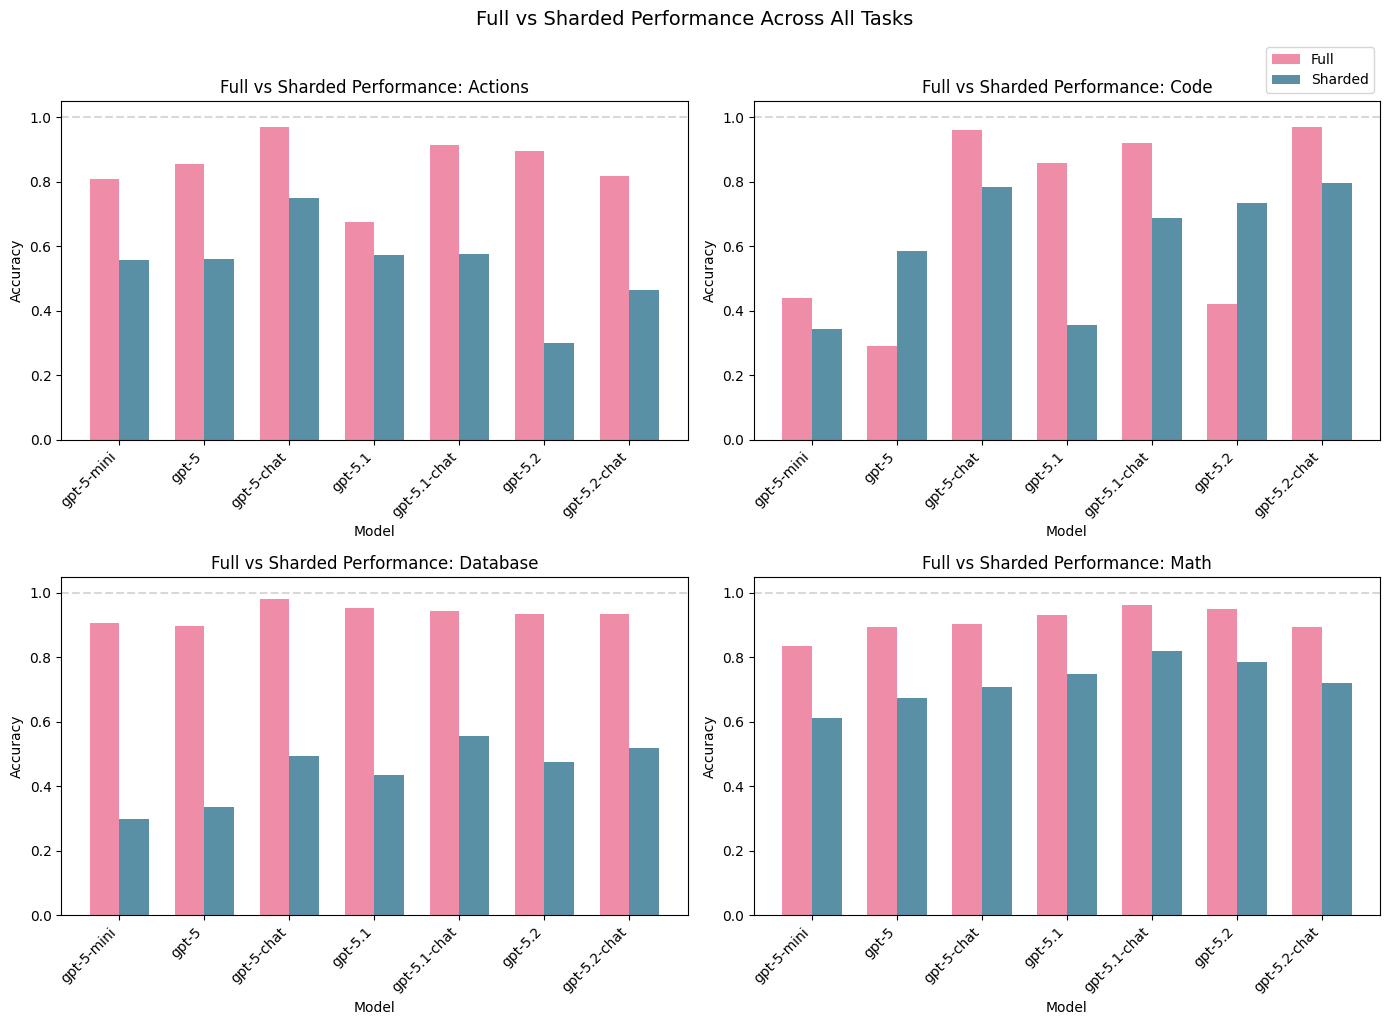

Saved to full_vs_sharded_all_tasks.png


In [10]:
# All tasks in a single figure (2x2 grid)
tasks = df_pivot["task"].unique()
n_tasks = len(tasks)
n_cols = 2
n_rows = (n_tasks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
axes = axes.flatten()

for i, task in enumerate(tasks):
    plot_task_bars(df_pivot, task, ax=axes[i], show_legend=(i == 0))

# Hide any unused subplots
for j in range(len(tasks), len(axes)):
    axes[j].set_visible(False)

# Add shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.99, 0.99))
axes[0].get_legend().remove()

plt.suptitle("Full vs Sharded Performance Across All Tasks", fontsize=14, y=1.02)
plt.tight_layout()
fig.savefig("full_vs_sharded_all_tasks.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to full_vs_sharded_all_tasks.png")